# Cuadrantes IPCC — España
## 13 regiones NUTS-2 · EUR PPS · Método 3

**Fuente:** Eurostat `nama_10r_2gdp` · CCPI calculado en `IPCC_ESPANA_FRANCIA_M3.ipynb`

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings, os
warnings.filterwarnings('ignore')

BASE_FIGURAS = '/Users/diego/Desktop/MT/prototipo_ccpi/figures'
BASE_DATA    = '/Users/diego/Desktop/MT/prototipo_ccpi/data'
os.makedirs(BASE_FIGURAS, exist_ok=True)

COLOR_TIER  = {1: '#8B1A1A', 2: '#E07B39', 3: '#A9A9A9'}
MARKER_TIER = {1: '*', 2: 'D', 3: 'o'}
SIZE_TIER   = {1: 280, 2: 160, 3: 90}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Serif', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.color': '#E8E0D8', 'grid.linewidth': 0.55,
})

# ── Carga de datos ─────────────────────────────────────────────────────────
df = pd.read_csv(f'{BASE_DATA}/ccpi_espana_m3.csv', encoding='utf-8-sig')

# ── Métricas derivadas ─────────────────────────────────────────────────────
# gdp_pc_2022 ya en EUR PPS
df['gdp_pc_abs'] = df['gdp_pc_2022']

# conv_pc ya calculada en IPCC_ESPANA_FRANCIA_M3 (brecha / n)
# la re-calculamos consistentemente con la muestra de 13 regiones españolas
med_gdp  = float(df['gdp_pc_2022'].median())
N_YEARS  = 9   # 2013-2022
df['conv_pc'] = (med_gdp - df['gdp_pc_2022']) / N_YEARS

med_tcac = float(df['tcac_pc'].median())
df['tcac_rel'] = df['tcac_pc'] - med_tcac

df['gdp_pc_rel'] = df['gdp_pc_2022'] / med_gdp

# Re-ranking dentro de España (13 regiones)
df['rank_M3'] = df['CCPI_M3'].rank(ascending=False).astype(int)

LEG_HANDLES = [
    Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_TIER[1],
           markersize=13, label='T1 — Referencia (Madrid)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=COLOR_TIER[2],
           markersize=9,  label='T2 — Ciudad secundaria'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_TIER[3],
           markersize=7,  label='T3 — Resto NUTS-2'),
]

print(f'✓ España: {len(df)} regiones cargadas')
print(f'  Mediana CCPI_M3: {df["CCPI_M3"].median():.3f}')
print(f'  Mediana PIB pc : €{med_gdp:,.0f} PPS')
print(f'  Mediana TCAC   : {med_tcac:.2%}')


✓ España: 13 regiones cargadas
  Mediana CCPI_M3: 0.522
  Mediana PIB pc : €29,300 PPS
  Mediana TCAC   : 3.39%


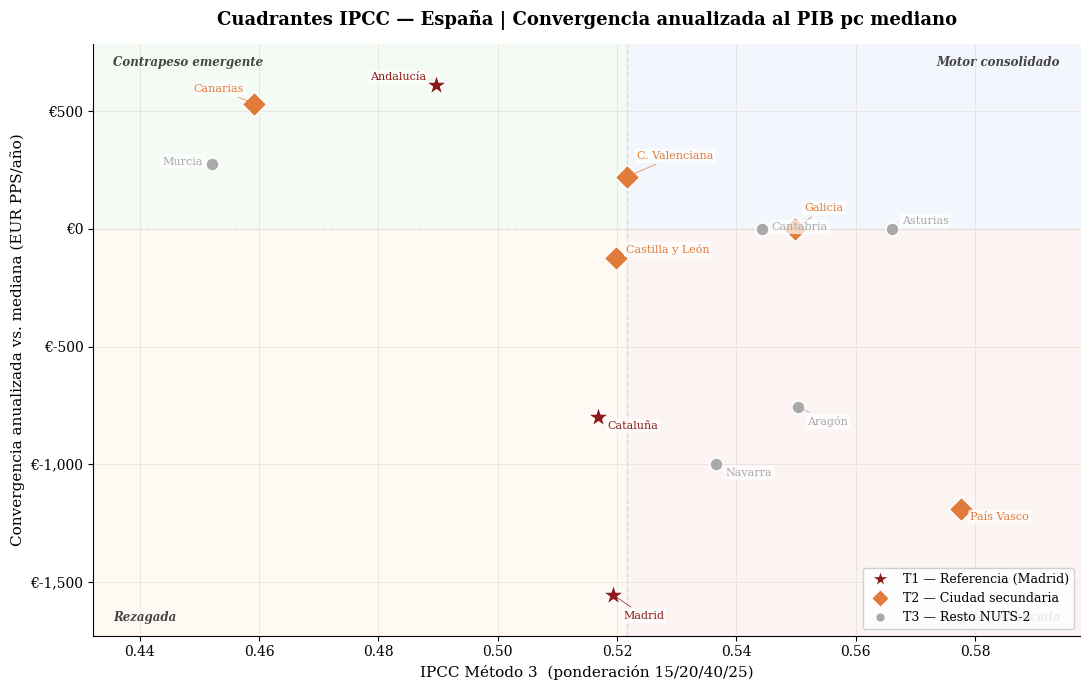

✓ F1 guardada → /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1_cuadrante_conv_ES.png


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# F1 — Cuadrantes IPCC — España · 13 NUTS-2\nF1: Convergencia anualizada al PIB pc mediano
# ══════════════════════════════════════════════════════════════════════════════

med_x_F1 = float(df['conv_pc'].median() * 1)
med_ccpi_F1 = float(df['CCPI_M3'].median())

fig_F1, ax_F1 = plt.subplots(figsize=(11, 7))
fig_F1.set_facecolor('white'); ax_F1.set_facecolor('white')
for sp in ['top','right']: ax_F1.spines[sp].set_visible(False)
ax_F1.grid(True, color='#E8E0D8', linewidth=0.55)

_ys = df['conv_pc'].values * 1
xmin_F1 = df['CCPI_M3'].min() - 0.02
xmax_F1 = df['CCPI_M3'].max() + 0.02
pad_y_F1 = (_ys.max() - _ys.min()) * 0.08
ymin_F1 = _ys.min() - pad_y_F1
ymax_F1 = _ys.max() + pad_y_F1

for (x0, x1, y0, y1), color in [
    ((xmin_F1, med_ccpi_F1, med_x_F1, ymax_F1), '#F2FBF2'),
    ((med_ccpi_F1, xmax_F1, med_x_F1, ymax_F1), '#F0F4FC'),
    ((xmin_F1, med_ccpi_F1, ymin_F1, med_x_F1), '#FEF8F0'),
    ((med_ccpi_F1, xmax_F1, ymin_F1, med_x_F1), '#FCF0F0'),
]:
    ax_F1.fill_betweenx([y0, y1], x0, x1, color=color, alpha=0.80, zorder=0)

ax_F1.axvline(med_ccpi_F1, color='#DDDDDD', lw=1, ls='--', zorder=1)
ax_F1.axhline(med_x_F1,   color='#DDDDDD', lw=1, ls='--', zorder=1)

kw_q = dict(fontsize=8.5, color='#444444', fontstyle='italic',
            fontweight='semibold', fontfamily='DejaVu Serif',
            transform=ax_F1.transAxes)
ax_F1.text(0.98, 0.98, 'Motor consolidado',    ha='right', va='top',    **kw_q)
ax_F1.text(0.02, 0.98, 'Contrapeso emergente', ha='left',  va='top',    **kw_q)
ax_F1.text(0.98, 0.02, 'Capital estancada',    ha='right', va='bottom', **kw_q)
ax_F1.text(0.02, 0.02, 'Rezagada',             ha='left',  va='bottom', **kw_q)

for _, row in df.iterrows():
    t = int(row['tier'])
    ax_F1.scatter(
        float(row['CCPI_M3']), float(row['conv_pc']) * 1,
        color=COLOR_TIER[t], s=SIZE_TIER[t], marker=MARKER_TIER[t],
        edgecolors='white', linewidth=1.2, zorder=5)

MIN_SEP = 9
cx_mid_F1 = (df['CCPI_M3'].min() + df['CCPI_M3'].max()) / 2
cy_mid_F1 = (_ys.min() + _ys.max()) / 2
rng_x_F1  = df['CCPI_M3'].max() - df['CCPI_M3'].min() + 1e-9
anns_F1 = []
for _, row in df.iterrows():
    t  = int(row['tier'])
    cx = float(row['CCPI_M3'])
    cy = float(row['conv_pc']) * 1
    dx = +7 if cx >= cx_mid_F1 else -7
    dy = +6 if cy >= cy_mid_F1 else -6
    anns_F1.append({'label': row['region'], 'cx': cx, 'cy': cy,
                     'dx': dx, 'dy': dy, 'color': COLOR_TIER[t]})

for _ in range(30):
    for i in range(len(anns_F1)):
        for j in range(i + 1, len(anns_F1)):
            a, b = anns_F1[i], anns_F1[j]
            if abs(a['cx'] - b['cx']) < rng_x_F1 * 0.06:
                if abs(a['dy'] - b['dy']) < MIN_SEP:
                    sep = MIN_SEP * 0.5
                    if a['cy'] >= b['cy']: a['dy'] += sep; b['dy'] -= sep
                    else:                  a['dy'] -= sep; b['dy'] += sep

for ann in anns_F1:
    ax_F1.annotate(ann['label'],
        xy=(ann['cx'], ann['cy']),
        xytext=(ann['dx'], ann['dy']),
        textcoords='offset points',
        fontsize=8, fontfamily='DejaVu Serif', color=ann['color'],
        va='center', ha='left' if ann['dx'] >= 0 else 'right',
        arrowprops=dict(arrowstyle='-', color=ann['color'],
                        lw=0.5, connectionstyle='arc3,rad=0.0'),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
        zorder=6)

ax_F1.legend(handles=LEG_HANDLES, fontsize=9, framealpha=0.9,
            loc='lower right', frameon=True)
ax_F1.set_xlabel('IPCC Método 3  (ponderación 15/20/40/25)',
                fontfamily='DejaVu Serif', fontsize=11)
ax_F1.set_ylabel('Convergencia anualizada vs. mediana (EUR PPS/año)', fontfamily='DejaVu Serif', fontsize=11)
ax_F1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax_F1.set_xlim(xmin_F1, xmax_F1)
ax_F1.set_ylim(ymin_F1, ymax_F1)
ax_F1.set_title('Cuadrantes IPCC — España | Convergencia anualizada al PIB pc mediano', fontfamily='DejaVu Serif',
              fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
ruta_F1 = '/Users/diego/Desktop/MT/prototipo_ccpi/figures/F1_cuadrante_conv_ES.png'
fig_F1.savefig(ruta_F1, dpi=300, bbox_inches='tight', facecolor='white')
display(fig_F1)
plt.close()
print(f'\u2713 F1 guardada \u2192 /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1_cuadrante_conv_ES.png')


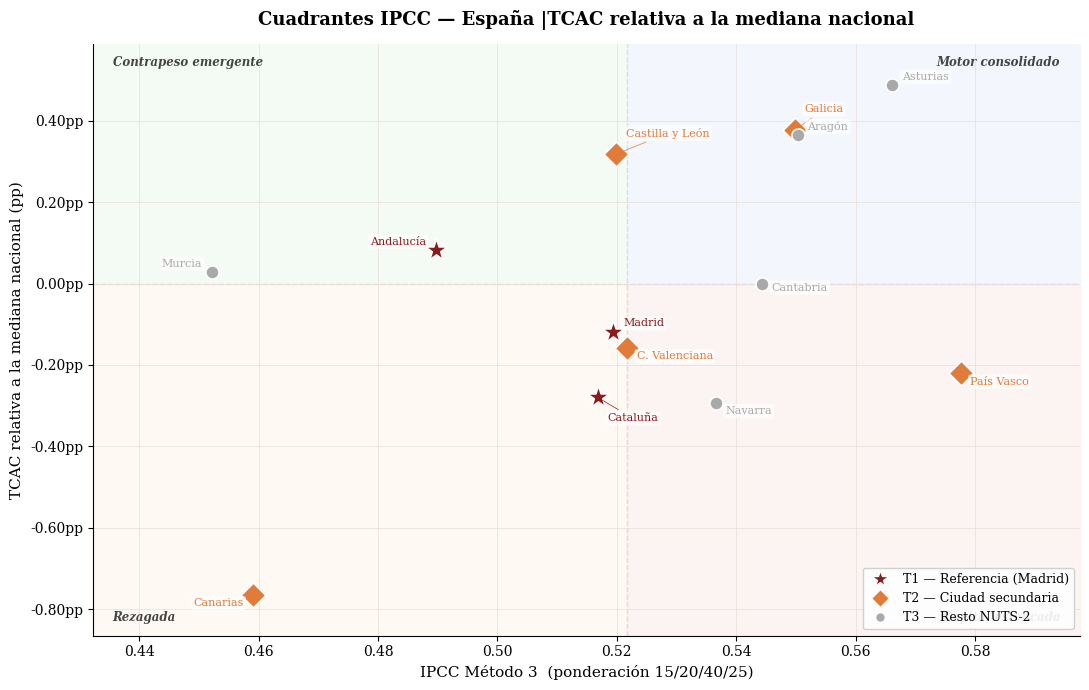

✓ F1b guardada → /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1b_cuadrante_tcac_rel_ES.png


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# F1b — Cuadrantes IPCC — España · 13 NUTS-2\nF1b: TCAC relativa a la mediana nacional
# ══════════════════════════════════════════════════════════════════════════════

med_x_F1b = float(df['tcac_rel'].median() * 100)
med_ccpi_F1b = float(df['CCPI_M3'].median())

fig_F1b, ax_F1b = plt.subplots(figsize=(11, 7))
fig_F1b.set_facecolor('white'); ax_F1b.set_facecolor('white')
for sp in ['top','right']: ax_F1b.spines[sp].set_visible(False)
ax_F1b.grid(True, color='#E8E0D8', linewidth=0.55)

_ys = df['tcac_rel'].values * 100
xmin_F1b = df['CCPI_M3'].min() - 0.02
xmax_F1b = df['CCPI_M3'].max() + 0.02
pad_y_F1b = (_ys.max() - _ys.min()) * 0.08
ymin_F1b = _ys.min() - pad_y_F1b
ymax_F1b = _ys.max() + pad_y_F1b

for (x0, x1, y0, y1), color in [
    ((xmin_F1b, med_ccpi_F1b, med_x_F1b, ymax_F1b), '#F2FBF2'),
    ((med_ccpi_F1b, xmax_F1b, med_x_F1b, ymax_F1b), '#F0F4FC'),
    ((xmin_F1b, med_ccpi_F1b, ymin_F1b, med_x_F1b), '#FEF8F0'),
    ((med_ccpi_F1b, xmax_F1b, ymin_F1b, med_x_F1b), '#FCF0F0'),
]:
    ax_F1b.fill_betweenx([y0, y1], x0, x1, color=color, alpha=0.80, zorder=0)

ax_F1b.axvline(med_ccpi_F1b, color='#DDDDDD', lw=1, ls='--', zorder=1)
ax_F1b.axhline(med_x_F1b,   color='#DDDDDD', lw=1, ls='--', zorder=1)

kw_q = dict(fontsize=8.5, color='#444444', fontstyle='italic',
            fontweight='semibold', fontfamily='DejaVu Serif',
            transform=ax_F1b.transAxes)
ax_F1b.text(0.98, 0.98, 'Motor consolidado',    ha='right', va='top',    **kw_q)
ax_F1b.text(0.02, 0.98, 'Contrapeso emergente', ha='left',  va='top',    **kw_q)
ax_F1b.text(0.98, 0.02, 'Capital estancada',    ha='right', va='bottom', **kw_q)
ax_F1b.text(0.02, 0.02, 'Rezagada',             ha='left',  va='bottom', **kw_q)

for _, row in df.iterrows():
    t = int(row['tier'])
    ax_F1b.scatter(
        float(row['CCPI_M3']), float(row['tcac_rel']) * 100,
        color=COLOR_TIER[t], s=SIZE_TIER[t], marker=MARKER_TIER[t],
        edgecolors='white', linewidth=1.2, zorder=5)

MIN_SEP = 9
cx_mid_F1b = (df['CCPI_M3'].min() + df['CCPI_M3'].max()) / 2
cy_mid_F1b = (_ys.min() + _ys.max()) / 2
rng_x_F1b  = df['CCPI_M3'].max() - df['CCPI_M3'].min() + 1e-9
anns_F1b = []
for _, row in df.iterrows():
    t  = int(row['tier'])
    cx = float(row['CCPI_M3'])
    cy = float(row['tcac_rel']) * 100
    dx = +7 if cx >= cx_mid_F1b else -7
    dy = +6 if cy >= cy_mid_F1b else -6
    anns_F1b.append({'label': row['region'], 'cx': cx, 'cy': cy,
                     'dx': dx, 'dy': dy, 'color': COLOR_TIER[t]})

for _ in range(30):
    for i in range(len(anns_F1b)):
        for j in range(i + 1, len(anns_F1b)):
            a, b = anns_F1b[i], anns_F1b[j]
            if abs(a['cx'] - b['cx']) < rng_x_F1b * 0.06:
                if abs(a['dy'] - b['dy']) < MIN_SEP:
                    sep = MIN_SEP * 0.5
                    if a['cy'] >= b['cy']: a['dy'] += sep; b['dy'] -= sep
                    else:                  a['dy'] -= sep; b['dy'] += sep

for ann in anns_F1b:
    ax_F1b.annotate(ann['label'],
        xy=(ann['cx'], ann['cy']),
        xytext=(ann['dx'], ann['dy']),
        textcoords='offset points',
        fontsize=8, fontfamily='DejaVu Serif', color=ann['color'],
        va='center', ha='left' if ann['dx'] >= 0 else 'right',
        arrowprops=dict(arrowstyle='-', color=ann['color'],
                        lw=0.5, connectionstyle='arc3,rad=0.0'),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
        zorder=6)

ax_F1b.legend(handles=LEG_HANDLES, fontsize=9, framealpha=0.9,
            loc='lower right', frameon=True)
ax_F1b.set_xlabel('IPCC Método 3  (ponderación 15/20/40/25)',
                fontfamily='DejaVu Serif', fontsize=11)
ax_F1b.set_ylabel('TCAC relativa a la mediana nacional (pp)', fontfamily='DejaVu Serif', fontsize=11)
ax_F1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}pp'))
ax_F1b.set_xlim(xmin_F1b, xmax_F1b)
ax_F1b.set_ylim(ymin_F1b, ymax_F1b)
ax_F1b.set_title('Cuadrantes IPCC — España |TCAC relativa a la mediana nacional', fontfamily='DejaVu Serif',
              fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
ruta_F1b = '/Users/diego/Desktop/MT/prototipo_ccpi/figures/F1b_cuadrante_tcac_rel_ES.png'
fig_F1b.savefig(ruta_F1b, dpi=300, bbox_inches='tight', facecolor='white')
display(fig_F1b)
plt.close()
print(f'\u2713 F1b guardada \u2192 /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1b_cuadrante_tcac_rel_ES.png')


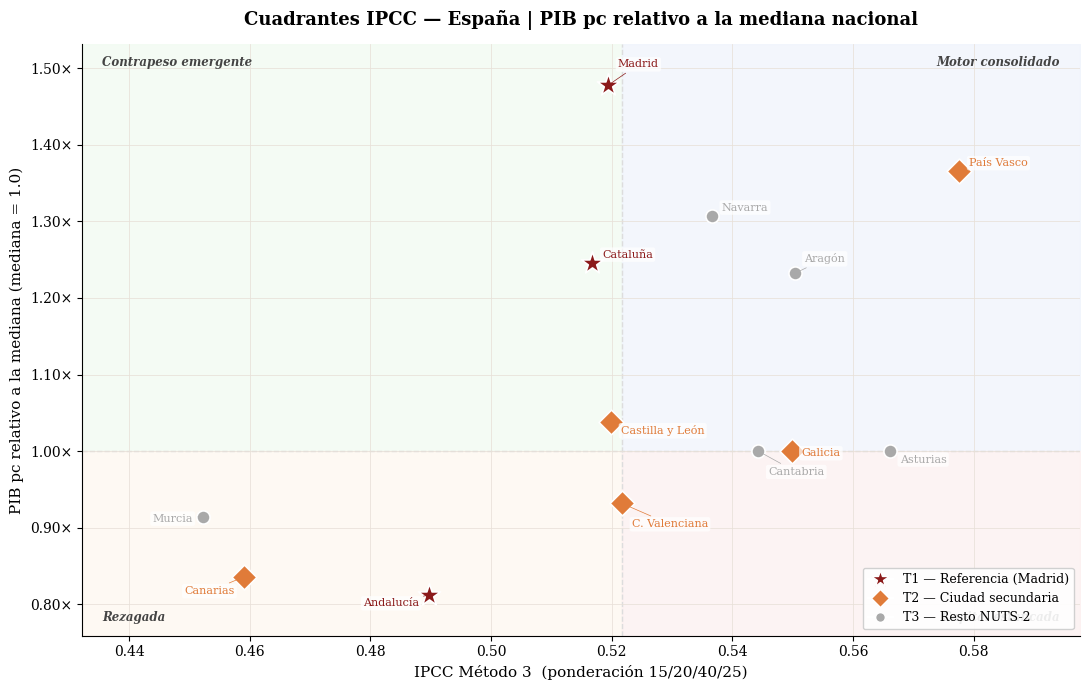

✓ F1c guardada → /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1c_cuadrante_pib_pc_ES.png


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# F1c — Cuadrantes IPCC — España · 13 NUTS-2\nF1c: PIB pc relativo a la mediana nacional
# ══════════════════════════════════════════════════════════════════════════════

med_x_F1c = float(df['gdp_pc_rel'].median() * 1)
med_ccpi_F1c = float(df['CCPI_M3'].median())

fig_F1c, ax_F1c = plt.subplots(figsize=(11, 7))
fig_F1c.set_facecolor('white'); ax_F1c.set_facecolor('white')
for sp in ['top','right']: ax_F1c.spines[sp].set_visible(False)
ax_F1c.grid(True, color='#E8E0D8', linewidth=0.55)

_ys = df['gdp_pc_rel'].values * 1
xmin_F1c = df['CCPI_M3'].min() - 0.02
xmax_F1c = df['CCPI_M3'].max() + 0.02
pad_y_F1c = (_ys.max() - _ys.min()) * 0.08
ymin_F1c = _ys.min() - pad_y_F1c
ymax_F1c = _ys.max() + pad_y_F1c

for (x0, x1, y0, y1), color in [
    ((xmin_F1c, med_ccpi_F1c, med_x_F1c, ymax_F1c), '#F2FBF2'),
    ((med_ccpi_F1c, xmax_F1c, med_x_F1c, ymax_F1c), '#F0F4FC'),
    ((xmin_F1c, med_ccpi_F1c, ymin_F1c, med_x_F1c), '#FEF8F0'),
    ((med_ccpi_F1c, xmax_F1c, ymin_F1c, med_x_F1c), '#FCF0F0'),
]:
    ax_F1c.fill_betweenx([y0, y1], x0, x1, color=color, alpha=0.80, zorder=0)

ax_F1c.axvline(med_ccpi_F1c, color='#DDDDDD', lw=1, ls='--', zorder=1)
ax_F1c.axhline(med_x_F1c,   color='#DDDDDD', lw=1, ls='--', zorder=1)

kw_q = dict(fontsize=8.5, color='#444444', fontstyle='italic',
            fontweight='semibold', fontfamily='DejaVu Serif',
            transform=ax_F1c.transAxes)
ax_F1c.text(0.98, 0.98, 'Motor consolidado',    ha='right', va='top',    **kw_q)
ax_F1c.text(0.02, 0.98, 'Contrapeso emergente', ha='left',  va='top',    **kw_q)
ax_F1c.text(0.98, 0.02, 'Capital estancada',    ha='right', va='bottom', **kw_q)
ax_F1c.text(0.02, 0.02, 'Rezagada',             ha='left',  va='bottom', **kw_q)

for _, row in df.iterrows():
    t = int(row['tier'])
    ax_F1c.scatter(
        float(row['CCPI_M3']), float(row['gdp_pc_rel']) * 1,
        color=COLOR_TIER[t], s=SIZE_TIER[t], marker=MARKER_TIER[t],
        edgecolors='white', linewidth=1.2, zorder=5)

MIN_SEP = 9
cx_mid_F1c = (df['CCPI_M3'].min() + df['CCPI_M3'].max()) / 2
cy_mid_F1c = (_ys.min() + _ys.max()) / 2
rng_x_F1c  = df['CCPI_M3'].max() - df['CCPI_M3'].min() + 1e-9
anns_F1c = []
for _, row in df.iterrows():
    t  = int(row['tier'])
    cx = float(row['CCPI_M3'])
    cy = float(row['gdp_pc_rel']) * 1
    dx = +7 if cx >= cx_mid_F1c else -7
    dy = +6 if cy >= cy_mid_F1c else -6
    anns_F1c.append({'label': row['region'], 'cx': cx, 'cy': cy,
                     'dx': dx, 'dy': dy, 'color': COLOR_TIER[t]})

for _ in range(30):
    for i in range(len(anns_F1c)):
        for j in range(i + 1, len(anns_F1c)):
            a, b = anns_F1c[i], anns_F1c[j]
            if abs(a['cx'] - b['cx']) < rng_x_F1c * 0.06:
                if abs(a['dy'] - b['dy']) < MIN_SEP:
                    sep = MIN_SEP * 0.5
                    if a['cy'] >= b['cy']: a['dy'] += sep; b['dy'] -= sep
                    else:                  a['dy'] -= sep; b['dy'] += sep

for ann in anns_F1c:
    ax_F1c.annotate(ann['label'],
        xy=(ann['cx'], ann['cy']),
        xytext=(ann['dx'], ann['dy']),
        textcoords='offset points',
        fontsize=8, fontfamily='DejaVu Serif', color=ann['color'],
        va='center', ha='left' if ann['dx'] >= 0 else 'right',
        arrowprops=dict(arrowstyle='-', color=ann['color'],
                        lw=0.5, connectionstyle='arc3,rad=0.0'),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
        zorder=6)

ax_F1c.legend(handles=LEG_HANDLES, fontsize=9, framealpha=0.9,
            loc='lower right', frameon=True)
ax_F1c.set_xlabel('IPCC Método 3  (ponderación 15/20/40/25)',
                fontfamily='DejaVu Serif', fontsize=11)
ax_F1c.set_ylabel('PIB pc relativo a la mediana (mediana = 1.0)', fontfamily='DejaVu Serif', fontsize=11)
ax_F1c.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}×'))
ax_F1c.set_xlim(xmin_F1c, xmax_F1c)
ax_F1c.set_ylim(ymin_F1c, ymax_F1c)
ax_F1c.set_title('Cuadrantes IPCC — España | PIB pc relativo a la mediana nacional', fontfamily='DejaVu Serif',
              fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
ruta_F1c = '/Users/diego/Desktop/MT/prototipo_ccpi/figures/F1c_cuadrante_pib_pc_ES.png'
fig_F1c.savefig(ruta_F1c, dpi=300, bbox_inches='tight', facecolor='white')
display(fig_F1c)
plt.close()
print(f'\u2713 F1c guardada \u2192 /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1c_cuadrante_pib_pc_ES.png')


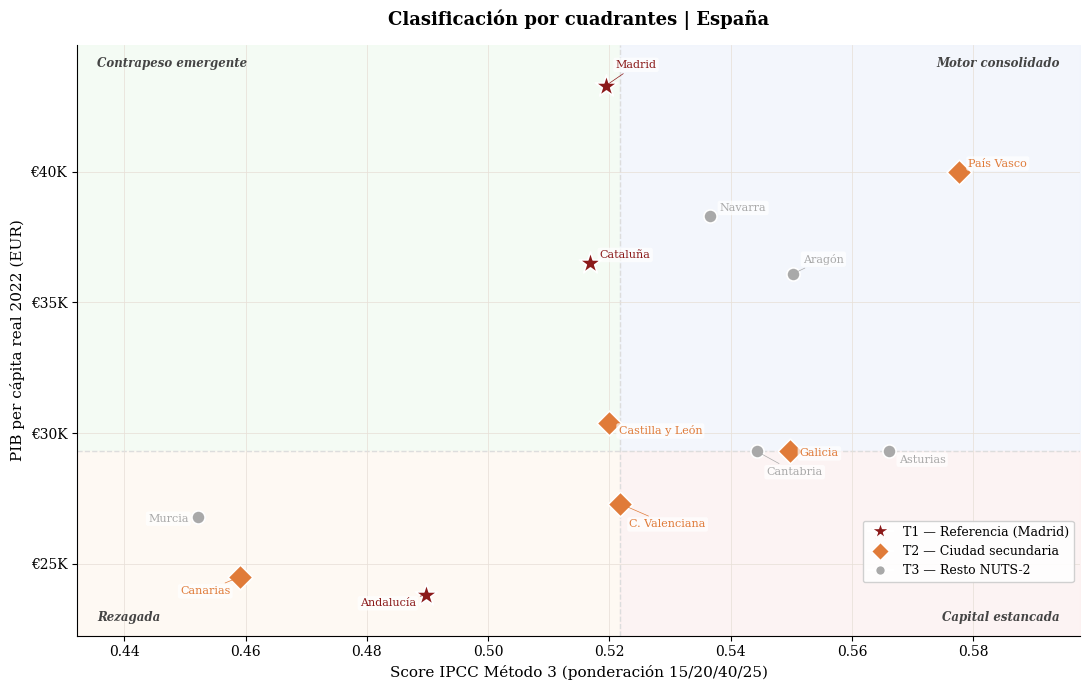

✓ F1d guardada → /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1d_cuadrante_pib_pc_abs_ES.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# F1d — Cuadrantes IPCC — España · 13 NUTS-2\nF1d: PIB pc absoluto 2022 (EUR PPS)
# ══════════════════════════════════════════════════════════════════════════════

med_x_F1d = float(df['gdp_pc_abs'].median() * 1)
med_ccpi_F1d = float(df['CCPI_M3'].median())

fig_F1d, ax_F1d = plt.subplots(figsize=(11, 7))
fig_F1d.set_facecolor('white'); ax_F1d.set_facecolor('white')
for sp in ['top','right']: ax_F1d.spines[sp].set_visible(False)
ax_F1d.grid(True, color='#E8E0D8', linewidth=0.55)

_ys = df['gdp_pc_abs'].values * 1
xmin_F1d = df['CCPI_M3'].min() - 0.02
xmax_F1d = df['CCPI_M3'].max() + 0.02
pad_y_F1d = (_ys.max() - _ys.min()) * 0.08
ymin_F1d = _ys.min() - pad_y_F1d
ymax_F1d = _ys.max() + pad_y_F1d

for (x0, x1, y0, y1), color in [
    ((xmin_F1d, med_ccpi_F1d, med_x_F1d, ymax_F1d), '#F2FBF2'),
    ((med_ccpi_F1d, xmax_F1d, med_x_F1d, ymax_F1d), '#F0F4FC'),
    ((xmin_F1d, med_ccpi_F1d, ymin_F1d, med_x_F1d), '#FEF8F0'),
    ((med_ccpi_F1d, xmax_F1d, ymin_F1d, med_x_F1d), '#FCF0F0'),
]:
    ax_F1d.fill_betweenx([y0, y1], x0, x1, color=color, alpha=0.80, zorder=0)

ax_F1d.axvline(med_ccpi_F1d, color='#DDDDDD', lw=1, ls='--', zorder=1)
ax_F1d.axhline(med_x_F1d,   color='#DDDDDD', lw=1, ls='--', zorder=1)

kw_q = dict(fontsize=8.5, color='#444444', fontstyle='italic',
            fontweight='semibold', fontfamily='DejaVu Serif',
            transform=ax_F1d.transAxes)
ax_F1d.text(0.98, 0.98, 'Motor consolidado',    ha='right', va='top',    **kw_q)
ax_F1d.text(0.02, 0.98, 'Contrapeso emergente', ha='left',  va='top',    **kw_q)
ax_F1d.text(0.98, 0.02, 'Capital estancada',    ha='right', va='bottom', **kw_q)
ax_F1d.text(0.02, 0.02, 'Rezagada',             ha='left',  va='bottom', **kw_q)

for _, row in df.iterrows():
    t = int(row['tier'])
    ax_F1d.scatter(
        float(row['CCPI_M3']), float(row['gdp_pc_abs']) * 1,
        color=COLOR_TIER[t], s=SIZE_TIER[t], marker=MARKER_TIER[t],
        edgecolors='white', linewidth=1.2, zorder=5)

MIN_SEP = 9
cx_mid_F1d = (df['CCPI_M3'].min() + df['CCPI_M3'].max()) / 2
cy_mid_F1d = (_ys.min() + _ys.max()) / 2
rng_x_F1d  = df['CCPI_M3'].max() - df['CCPI_M3'].min() + 1e-9
anns_F1d = []
for _, row in df.iterrows():
    t  = int(row['tier'])
    cx = float(row['CCPI_M3'])
    cy = float(row['gdp_pc_abs']) * 1
    dx = +7 if cx >= cx_mid_F1d else -7
    dy = +6 if cy >= cy_mid_F1d else -6
    anns_F1d.append({'label': row['region'], 'cx': cx, 'cy': cy,
                     'dx': dx, 'dy': dy, 'color': COLOR_TIER[t]})

for _ in range(30):
    for i in range(len(anns_F1d)):
        for j in range(i + 1, len(anns_F1d)):
            a, b = anns_F1d[i], anns_F1d[j]
            if abs(a['cx'] - b['cx']) < rng_x_F1d * 0.06:
                if abs(a['dy'] - b['dy']) < MIN_SEP:
                    sep = MIN_SEP * 0.5
                    if a['cy'] >= b['cy']: a['dy'] += sep; b['dy'] -= sep
                    else:                  a['dy'] -= sep; b['dy'] += sep

for ann in anns_F1d:
    ax_F1d.annotate(ann['label'],
        xy=(ann['cx'], ann['cy']),
        xytext=(ann['dx'], ann['dy']),
        textcoords='offset points',
        fontsize=8, fontfamily='DejaVu Serif', color=ann['color'],
        va='center', ha='left' if ann['dx'] >= 0 else 'right',
        arrowprops=dict(arrowstyle='-', color=ann['color'],
                        lw=0.5, connectionstyle='arc3,rad=0.0'),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
        zorder=6)

ax_F1d.legend(handles=LEG_HANDLES, fontsize=9, framealpha=0.9,
            loc='lower right', frameon=True,
            bbox_to_anchor=(1.0, 0.08))
ax_F1d.set_xlabel('Score IPCC Método 3 (ponderación 15/20/40/25)',
                fontfamily='DejaVu Serif', fontsize=11)
ax_F1d.set_ylabel('PIB per cápita real 2022 (EUR)', fontfamily='DejaVu Serif', fontsize=11)
ax_F1d.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1_000:.0f}K'))
ax_F1d.set_xlim(xmin_F1d, xmax_F1d)
ax_F1d.set_ylim(ymin_F1d, ymax_F1d)
ax_F1d.set_title('Clasificación por cuadrantes | España', fontfamily='DejaVu Serif',
              fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
ruta_F1d = '/Users/diego/Desktop/MT/prototipo_ccpi/figures/F1d_cuadrante_pib_pc_abs_ES.png'
fig_F1d.savefig(ruta_F1d, dpi=300, bbox_inches='tight', facecolor='white')
display(fig_F1d)
plt.close()
print(f'\u2713 F1d guardada \u2192 /Users/diego/Desktop/MT/prototipo_ccpi/figures/F1d_cuadrante_pib_pc_abs_ES.png')


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN FINAL — 13 regiones NUTS-2 · España
# ══════════════════════════════════════════════════════════════════════════════
print()
print('╔' + '═'*82 + '╗')
print('║  IPCC · ESPAÑA · MÉTODO 3 · 13 regiones NUTS-2' + ' '*34 + '║')
print('╠' + '═'*82 + '╣')
print(f'  {"Rank":>4}  {"Tier":<5}  {"Región":<22}  {"CCPI_M3":>8}  '
      f'{"conv_pc":>10}  {"tcac_rel":>8}  {"gdp_pc_rel":>10}  {"gdp_pc_abs":>12}')
print('  ' + '─'*82)
for _, row in df.sort_values('rank_M3').iterrows():
    print(f'  #{int(row["rank_M3"]):>3}  T{int(row["tier"])}     '
          f'{row["region"]:<22}  {row["CCPI_M3"]:>8.3f}  '
          f'€{row["conv_pc"]:>9,.0f}  {row["tcac_rel"]*100:>7.3f}pp  '
          f'{row["gdp_pc_rel"]:>10.3f}×  €{row["gdp_pc_abs"]/1000:>9.1f}K')
print('╚' + '═'*82 + '╝')



╔══════════════════════════════════════════════════════════════════════════════════╗
║  IPCC · ESPAÑA · MÉTODO 3 · 13 regiones NUTS-2                                  ║
╠══════════════════════════════════════════════════════════════════════════════════╣
  Rank  Tier   Región                   CCPI_M3     conv_pc  tcac_rel  gdp_pc_rel    gdp_pc_abs
  ──────────────────────────────────────────────────────────────────────────────────
  #  1  T2     País Vasco                 0.578  €   -1,189   -0.221pp       1.365×  €     40.0K
  #  2  T3     Asturias                   0.566  €        0    0.488pp       1.000×  €     29.3K
  #  3  T3     Aragón                     0.550  €     -756    0.366pp       1.232×  €     36.1K
  #  4  T2     Galicia                    0.550  €        0    0.377pp       1.000×  €     29.3K
  #  5  T3     Cantabria                  0.544  €        0    0.000pp       1.000×  €     29.3K
  #  6  T3     Navarra                    0.537  €   -1,000   -0.293pp       1.